In [1]:
#Instalacja bibliotek w Jupyter
!pip install numpy
!pip install matplotlib
!pip install ipywidgets
!pip install ipywidgets jupyterlab_widgets
!pip install scipy # instalacja biblioteki scipy
!pip install pydicom


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 24.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#Inicjalizacja bibliotek
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ipywidgets import interact, IntSlider
import pydicom
import io

## Preprocessing obrazu

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

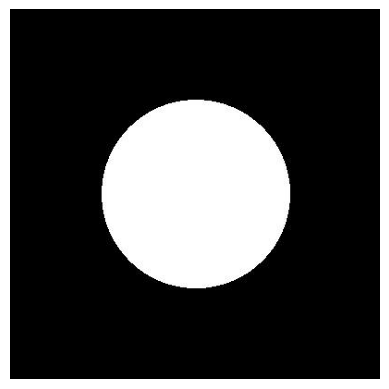

In [2]:
#Wczytanie obrazu
img = Image.open("./obraz/Kolo.jpg")
plt.imshow(img)
plt.axis("off")

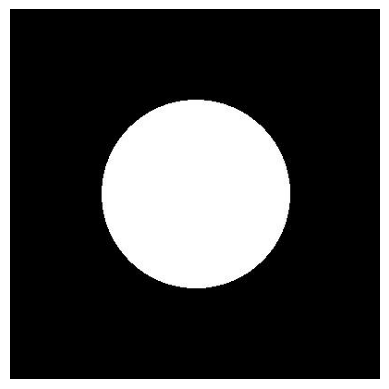

In [3]:
#Zamiana w skalę szarości i zamiana w array
gray = img.convert("L")
plt.imshow(gray, cmap="gray")
plt.axis("off")

arr = np.array(gray).astype(np.float64)

In [4]:
ds = pydicom.dcmread("./dicom/SADDLE_PE.dcm")
img = ds.pixel_array.astype(np.float64)

if hasattr(ds, "RescaleSlope") and hasattr(ds, "RescaleIntercept"):
    img = img * ds.RescaleSlope + ds.RescaleIntercept

plt.imshow(img, cmap="gray")
plt.axis("off")

img_min, img_max = img.min(), img.max()
arr = (img - img_min) / (img_max - img_min + 1e-8)

FileNotFoundError: [Errno 2] No such file or directory: './dicom/SADDLE_PE.dcm'

## Transformata Radona

In [5]:
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets
import numpy as np

emiters_number = 100
l = 200
delta_alpha = 1


progress_slider = widgets.IntSlider(
    min=1, max=180, step=1, value=180, 
    description="Postęp (kąt)",
    disabled=True # Aktywujemy go dopiero po obliczeniu sinogramu
)

def update_iterative_recon(change=None):
    if sinogram_cache[0] is None:
        return
        
    with out_recon:
        out_recon.clear_output(wait=True)
        
        # Pobieramy wartość z suwaka postępu
        current_steps = progress_slider.value
        full_sino = sinogram_cache[0]
        
        # Obliczamy ile kątów aktualnie bierzemy pod uwagę
        n_angles_total = full_sino.shape[0]
        # Mapujemy wartość suwaka na zakres dostępnych rzędów sinogramu
        idx = int((current_steps / progress_slider.max) * n_angles_total)
        idx = max(1, idx) # Minimum 1 rząd
        
        # Wycinamy fragment sinogramu (od 0 do idx)
        partial_sino = full_sino[:idx, :]
        
        # Jeśli filtrowanie jest włączone
        if filter_checkbox.value:
            partial_sino = filter_sinogram(partial_sino)
            title = f"FBP - Postęp: {current_steps}°"
        else:
            title = f"Simple Backprojection - Postęp: {current_steps}°"
            
        # Wykonujemy rekonstrukcję tylko dla wycinka
        recon = backproject(partial_sino,
                            delta_alpha=delta_slider.value,
                            output_size=max(arr.shape),
                            max_angle=current_steps) # max_angle ogranicza zakres w backproject
        
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(recon, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
        plt.show()

# Rejestrujemy obserwatora suwaka
progress_slider.observe(update_iterative_recon, names='value')

# Nowy suwak dla sinogramu
sino_progress_slider = widgets.IntSlider(
    min=1, max=180, step=1, value=180, 
    description="Sinogram (°)",
    disabled=True # Aktywowany po obliczeniu sinogramu
)

def update_iterative_sino(change=None):
    if sinogram_cache[0] is None:
        return
        
    with out_sino:
        out_sino.clear_output(wait=True)
        
        current_steps = sino_progress_slider.value
        full_sino = sinogram_cache[0]
        
        # Proporcjonalne mapowanie kątów na rzędy macierzy
        n_angles_total = full_sino.shape[0]
        idx = int((current_steps / sino_progress_slider.max) * n_angles_total)
        idx = max(1, idx)
        
        # Tworzymy czarną (zerową) planszę o rozmiarach pełnego sinogramu
        display_sino = np.zeros_like(full_sino)
        # Wklejamy tylko obliczony fragment
        display_sino[:idx, :] = full_sino[:idx, :]
        
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(display_sino, cmap='gray', aspect='auto')
        ax.set_title(f"Sinogram - Postęp: {current_steps}°")
        ax.set_xlabel("Detektory")
        ax.set_ylabel("Kąt")
        plt.show()

# Rejestracja obserwatora
sino_progress_slider.observe(update_iterative_sino, names='value')

# --- Sekcja ładowania plików ---

# Widżety do wgrywania
upload_dicom = widgets.FileUpload(accept='.dcm', multiple=False, description="Wczytaj DICOM")
upload_jpg = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False, description="Wczytaj JPG/PNG")
status_label = widgets.Label(value="Status: Oczekiwanie na obraz...")

# Inicjalizacja pustego obrazu (domyślny placeholder)
arr = np.zeros((200, 200))

def process_upload(change, file_type='img'):
    global arr
    # Pobranie danych z widżetu FileUpload
    uploaded_file = next(iter(change['new']))
    content = uploaded_file['content']
    
    try:
        if file_type == 'dicom':
            # Dekodowanie formatu DICOM
            with io.BytesIO(content) as f:
                ds = pydicom.dcmread(f)
                arr = ds.pixel_array.astype(float)
        else:
            # Dekodowanie JPG/PNG i konwersja na odcienie szarości
            img = Image.open(io.BytesIO(content)).convert('L')
            arr = np.array(img).astype(float)

        # Normalizacja do zakresu [0, 1] dla spójności obliczeń
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        
        status_label.value = f"Status: Załadowano {uploaded_file['name']} ({arr.shape[1]}x{arr.shape[0]})"
        
        # Automatyczne odświeżenie podglądu geometrii
        update_geometry()
        
    except Exception as e:
        status_label.value = f"Błąd wczytywania: {str(e)}"

# Reakcja na zmianę zawartości widżetów
upload_dicom.observe(lambda change: process_upload(change, 'dicom'), names='value')
upload_jpg.observe(lambda change: process_upload(change, 'img'), names='value')

def bresenham_line(x0, y0, x1, y1):
    points = []
    x0, y0, x1, y1 = int(round(x0)), int(round(y0)), int(round(x1)), int(round(y1))
    dx = abs(x1 - x0); dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy
    while True:
        points.append((x0, y0))
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy: err -= dy; x0 += sx
        if e2 <  dx: err += dx; y0 += sy
    return points

def radon_transform(arr, emiters_number, delta_alpha, l=None, max_angle=180):
    height, width = arr.shape
    cx = width // 2; cy = height // 2
    if l is None:
        l = int(np.sqrt(width**2 + height**2))
    
    angles = np.deg2rad(np.arange(0, max_angle, delta_alpha))
    emiters = np.linspace(-l/2, l/2, emiters_number)
    sinogram = []
    
    for theta in angles:
        dx = np.cos(theta); dy = np.sin(theta)
        px = -dy;           py = dx
        row = []
        for t in emiters:
            x0 = cx + t * px - dx * (l / 2)
            y0 = cy + t * py - dy * (l / 2)
            x1 = cx + t * px + dx * (l / 2)
            y1 = cy + t * py + dy * (l / 2)
            points = bresenham_line(x0, y0, x1, y1)
            s = sum(arr[y, x] for x, y in points if 0 <= x < width and 0 <= y < height)
            row.append(s)
        sinogram.append(row)
    return np.array(sinogram)

def filter_sinogram(sinogram, kernel_size=61, l=None):
    n_angles, n_detectors = sinogram.shape

    h = np.zeros(kernel_size)
    center = kernel_size // 2
    for i in range(kernel_size):
        n = i - center
        if n == 0:
            h[i] = 1.0 / 4
        elif n % 2 == 0:
            h[i] = 0.0
        else:
            h[i] = -1.0 / (np.pi**2 * n**2)

    filtered = np.zeros_like(sinogram, dtype=np.float64)
    for i in range(n_angles):
        filtered[i] = np.convolve(sinogram[i], h, mode='same')
    return filtered

def backproject(sinogram, delta_alpha, output_size, max_angle=180):
    height = width = output_size
    cx = width // 2; cy = height // 2
    reconstruction = np.zeros((height, width), dtype=np.float64)
    
    l = int(np.sqrt(width**2 + height**2))
    
    angles = np.deg2rad(np.arange(0, max_angle, delta_alpha))
    n_detectors = sinogram.shape[1]
    
    emiters = np.linspace(-l/2, l/2, n_detectors)

    ys, xs = np.mgrid[0:height, 0:width]
    xs = xs - cx; ys = ys - cy

    for i, theta in enumerate(angles):
        if i >= sinogram.shape[0]: break
        dx = np.cos(theta); dy = np.sin(theta)
        px = -dy;           py = dx
        t = xs * px + ys * py
        indices = np.interp(t, emiters, np.arange(n_detectors))
        i0 = np.clip(indices.astype(int), 0, n_detectors - 2)
        i1 = i0 + 1
        frac = indices - i0
        row = sinogram[i]
        vals = row[i0] * (1 - frac) + row[i1] * frac
        reconstruction += vals

    reconstruction /= len(angles) 

    reconstruction -= reconstruction.min()
    if reconstruction.max() > 0:
        reconstruction /= reconstruction.max()
    return reconstruction

out_geom   = widgets.Output()
out_sino   = widgets.Output()
out_recon  = widgets.Output()

emiters_slider = widgets.IntSlider(min=100, max=1000, step=10,  value=100, description="Emiters")
delta_slider   = widgets.FloatSlider(min=0.5,  max=10,  step=0.5,   value=1,   description="dα")
theta_slider   = widgets.IntSlider(min=0,  max=360, step=1,   value=180,   description="θ")

run_button    = widgets.Button(description="Compute Sinogram",  button_style='success')
recon_button  = widgets.Button(description="Reconstruct Image", button_style='info')
all_button  = widgets.Button(description="Do Both", button_style='info')
sinogram_cache = [None]

def update_geometry(change=None):
    with out_geom:
        out_geom.clear_output(wait=True)
        en = emiters_slider.value
        max_angle = theta_slider.value
        height, width = arr.shape
        cx = width // 2; cy = height // 2
        l_geom = int(np.sqrt(width**2 + height**2))
        emiters = np.linspace(-l_geom/2, l_geom/2, en)
        angles = np.deg2rad(np.arange(0, max_angle, delta_slider.value))

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(arr, cmap='gray')
        ax.set_title(f"Geometry max_angle={max_angle}°")

        if len(angles) == 0:
            ax.set_xlim(0, width)
            ax.set_ylim(height, 0)
            ax.axis('off')
            plt.show()
            return

        angle_step  = max(1, len(angles) // 20)
        emiter_step = max(1, en // 10)

        for theta in angles[::angle_step]:
            dx = np.cos(theta); dy = np.sin(theta)
            px = -dy;           py = dx
            for t in emiters[::emiter_step]:
                x0 = cx + t * px - dx * (l_geom / 2)
                y0 = cy + t * py - dy * (l_geom / 2)
                x1 = cx + t * px + dx * (l_geom / 2)
                y1 = cy + t * py + dy * (l_geom / 2)
                ax.plot([x0, x1], [y0, y1],
                        linewidth=0.8, alpha=0.6,
                        color='cyan')  # jeden stały kolor

        # okrąg skanera
        circle = plt.Circle((cx, cy), l_geom/2, fill=False,
                             color='white', linewidth=0.8,
                             linestyle='--', alpha=0.5)
        ax.add_patch(circle)

        ax.set_xlim(0, width)
        ax.set_ylim(height, 0)
        ax.axis('off')
        plt.show()

def on_run_clicked(b):
    with out_sino:
        out_sino.clear_output(wait=True)
        print("Obliczanie sinogramu...")
        
    sino = radon_transform(arr,
                           emiters_number=emiters_slider.value,
                           delta_alpha=delta_slider.value, 
                           max_angle=theta_slider.value)
    sinogram_cache[0] = sino
    
    # Aktualizacja suwaka REKONSTRUKCJI
    progress_slider.max = theta_slider.value
    progress_slider.value = theta_slider.value
    progress_slider.disabled = False
    
    # Aktualizacja NOWEGO suwaka SINOGRAMU
    sino_progress_slider.max = theta_slider.value
    sino_progress_slider.value = theta_slider.value
    sino_progress_slider.disabled = False
    
    # Wymuszenie narysowania sinogramu
    update_iterative_sino()

def on_all_clicked(b):
    with out_sino:
        out_sino.clear_output(wait=True)
        sino = radon_transform(arr,
                               emiters_number=emiters_slider.value,
                               delta_alpha=delta_slider.value, max_angle=theta_slider.value)
        sinogram_cache[0] = sino
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(sino, cmap='gray', aspect='auto')
        ax.set_title("Sinogram")
        ax.set_xlabel("Detectors"); ax.set_ylabel("Angle")
        plt.show()

    with out_recon:
        out_recon.clear_output(wait=True)
        if filter_checkbox.value:
            print("Rekonstrukcja z filtrowaniem...")
            processed_sino = filter_sinogram(sinogram_cache[0])
            title = "Rekonstrukcja FBP (z filtrem)"
        else:
            print("Rekonstrukcja bez filtrowania (Simple Backprojection)...")
            processed_sino = sinogram_cache[0]
            title = "Rekonstrukcja (bez filtra)"

        recon = backproject(processed_sino,
                            delta_alpha=delta_slider.value,
                            output_size=max(arr.shape))

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(recon, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
        plt.show()

def on_recon_clicked(b):
    with out_recon:
        out_recon.clear_output(wait=True)
        if sinogram_cache[0] is None:
            print("Najpierw oblicz sinogram przyciskiem 'Compute Sinogram'.")
            return

        if filter_checkbox.value:
            print("Rekonstrukcja z filtrowaniem...")
            processed_sino = filter_sinogram(sinogram_cache[0])
            title = "Rekonstrukcja FBP (z filtrem)"
        else:
            print("Rekonstrukcja bez filtrowania (Simple Backprojection)...")
            processed_sino = sinogram_cache[0]
            title = "Rekonstrukcja (bez filtra)"
        
        recon = backproject(processed_sino,
                            delta_alpha=delta_slider.value,
                            output_size=max(arr.shape), max_angle=theta_slider.value)
        
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(recon, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
        plt.show()
        
filter_checkbox = widgets.Checkbox(value=True, description="Użyj filtrowania")
emiters_slider.observe(update_geometry, names='value')
theta_slider.observe(update_geometry,   names='value')
run_button.on_click(on_run_clicked)
recon_button.on_click(on_recon_clicked)
all_button.on_click(on_all_clicked)
display(widgets.VBox([
    widgets.HTML("<b>1. Wczytaj dane wejściowe:</b>"),
    widgets.HBox([upload_dicom, upload_jpg]),
    status_label,
    widgets.HTML("<hr><b>2. Parametry symulacji:</b>"),
    progress_slider,
    emiters_slider,
    delta_slider,
    theta_slider,
    filter_checkbox,
    widgets.HBox([run_button, recon_button, all_button]),
    out_geom,
    sino_progress_slider,
    out_sino,
    out_recon,
]))

update_geometry()

def calculate_rmse(original, reconstruction):

    h, w = original.shape
    rh, rw = reconstruction.shape
    
    y_start = (rh - h) // 2
    x_start = (rw - w) // 2
    recon_matched = reconstruction[y_start:y_start+h, x_start:x_start+w]
    
    orig_norm = (original - np.min(original)) / (np.max(original) - np.min(original) + 1e-8)
    recon_norm = (recon_matched - np.min(recon_matched)) / (np.max(recon_matched) - np.min(recon_matched) + 1e-8)

    mse = np.mean((orig_norm - recon_norm) ** 2)
    return np.sqrt(mse)

def run_experiments(base_image):
    default_det = 180
    default_scans = 180
    default_range = 180
    out_size = base_image.shape[0]
    l_val = int(np.sqrt(out_size**2 + out_size**2))

    plt.figure(figsize=(15, 5))

    det_values = [360]
    rmse_det = []
    rmse_det_f = []
    print("Testowanie liczby detektorów...")
    for d in det_values:
        sino = radon_transform(base_image, emiters_number=d, delta_alpha=1.0)
        filtered = filter_sinogram(sino, l=l_val)
        recon = backproject(sino, delta_alpha=1.0, output_size=out_size)
        recon_f = backproject(filtered, delta_alpha=1.0, output_size=out_size)
        rmse_det.append(calculate_rmse(base_image, recon))
        rmse_det_f.append(calculate_rmse(base_image, recon_f))

    print(f"RMSE dla liczby detektorów {det_values}: {float(rmse_det[0])}")
    print(f"RMSE dla liczby detektorów (z filtrem) {det_values}: {float(rmse_det_f[0])}")

    scan_values = [360]
    rmse_scans = []
    rmse_scans_f = []
    print("Testowanie liczby skanów...")
    for s in scan_values:
        d_alpha = 180 / s
        sino = radon_transform(base_image, emiters_number=180, delta_alpha=d_alpha)
        filtered = filter_sinogram(sino, l=l_val)
        recon = backproject(sino, delta_alpha=d_alpha, output_size=out_size)
        recon_f = backproject(filtered, delta_alpha=d_alpha, output_size=out_size)
        rmse_scans.append(calculate_rmse(base_image, recon))
        rmse_scans_f.append(calculate_rmse(base_image, recon_f))

    print(f"RMSE dla liczby skanów {scan_values}: {float(rmse_scans[0])}")
    print(f"RMSE dla liczby skanów (z filtrem) {scan_values}: {float(rmse_scans_f[0])}")

    range_values = [270]
    rmse_range = []
    rmse_range_f = []
    print("Testowanie rozpiętości wachlarza...")
    for r in range_values:
        sino = radon_transform(base_image, emiters_number=180, delta_alpha=1, max_angle=r)
        filtered = filter_sinogram(sino, l=l_val)
        recon = backproject(sino, delta_alpha=1, output_size=out_size, max_angle=r)
        recon_f = backproject(filtered, delta_alpha=1, output_size=out_size, max_angle=r)

        rmse_range.append(calculate_rmse(base_image, recon))
        rmse_range_f.append(calculate_rmse(base_image, recon_f))

    print(f"RMSE dla rozpiętości wachlarza {range_values}: {float(rmse_range[0])}")
    print(f"RMSE dla rozpiętości wachlarza (z filtrem) {range_values}: {float(rmse_range_f[0])}")

    plt.tight_layout()
    plt.show()


